In [130]:
print("python funciona correctamente")


python funciona correctamente


# Credit Risk Default Prediction

## 1. Data Loading and Initial Inspection

In [131]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

print("Librerías cargadas correctamente")

Librerías cargadas correctamente


In [132]:
import sys
!{sys.executable} -m pip install pandas numpy matplotlib scikit-learn

In [133]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

print("Librerías cargadas correctamente")

Librerías cargadas correctamente


In [134]:
import sys
print(sys.executable)


c:\Users\sathy\AppData\Local\Programs\Python\Python313\python.exe


In [135]:
import pandas as pd


In [136]:
df=pd.read_csv("credit_risk_dataset.csv")

In [137]:
df.head()

,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length
0,22,59000,RENT,123.0,PERSONAL,D,35000,16.02,1,0.59,Y,3
1,21,9600,OWN,5.0,EDUCATION,B,1000,11.14,0,0.10,N,2
2,25,9600,MORTGAGE,1.0,MEDICAL,C,5500,12.87,1,0.57,N,3
3,23,65500,RENT,4.0,MEDICAL,C,35000,15.23,1,0.53,N,2
4,24,54400,RENT,8.0,MEDICAL,C,35000,14.27,1,0.55,Y,4


In [138]:
df.shape



(32581, 12)

In [139]:
df.columns

Index(['person_age', 'person_income', 'person_home_ownership',
       'person_emp_length', 'loan_intent', 'loan_grade', 'loan_amnt',
       'loan_int_rate', 'loan_status', 'loan_percent_income',
       'cb_person_default_on_file', 'cb_person_cred_hist_length'],
      dtype='str')

In [140]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 32581 entries, 0 to 32580
Data columns (total 12 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   person_age                  32581 non-null  int64  
 1   person_income               32581 non-null  int64  
 2   person_home_ownership       32581 non-null  str    
 3   person_emp_length           31686 non-null  float64
 4   loan_intent                 32581 non-null  str    
 5   loan_grade                  32581 non-null  str    
 6   loan_amnt                   32581 non-null  int64  
 7   loan_int_rate               29465 non-null  float64
 8   loan_status                 32581 non-null  int64  
 9   loan_percent_income         32581 non-null  float64
 10  cb_person_default_on_file   32581 non-null  str    
 11  cb_person_cred_hist_length  32581 non-null  int64  
dtypes: float64(3), int64(5), str(4)
memory usage: 3.0 MB


In [141]:
df.isnull().sum()

person_age                       0
person_income                    0
person_home_ownership            0
person_emp_length              895
loan_intent                      0
loan_grade                       0
loan_amnt                        0
loan_int_rate                 3116
loan_status                      0
loan_percent_income              0
cb_person_default_on_file        0
cb_person_cred_hist_length       0
dtype: int64

In [142]:
df["loan_status"].value_counts()

loan_status
0    25473
1     7108
Name: count, dtype: int64

In [143]:
df.describe()

,person_age,person_income,person_emp_length,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_cred_hist_length
count,32581.000000,3.258100e+04,31686.000000,32581.000000,29465.000000,32581.000000,32581.000000,32581.000000
mean,27.734600,6.607485e+04,4.789686,9589.371106,11.011695,0.218164,0.170203,5.804211
std,6.348078,6.198312e+04,4.142630,6322.086646,3.240459,0.413006,0.106782,4.055001
min,20.000000,4.000000e+03,0.000000,500.000000,5.420000,0.000000,0.000000,2.000000
25%,23.000000,3.850000e+04,2.000000,5000.000000,7.900000,0.000000,0.090000,3.000000
50%,26.000000,5.500000e+04,4.000000,8000.000000,10.990000,0.000000,0.150000,4.000000
75%,30.000000,7.920000e+04,7.000000,12200.000000,13.470000,0.000000,0.230000,8.000000
max,144.000000,6.000000e+06,123.000000,35000.000000,23.220000,1.000000,0.830000,30.000000


## 2. Exploratory Data Analysis

In [144]:
df[df["person_age"]>100]

,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length
81,144,250000,RENT,4.0,VENTURE,C,4800,13.57,0,0.02,N,3
183,144,200000,MORTGAGE,4.0,EDUCATION,B,6000,11.86,0,0.03,N,2
575,123,80004,RENT,2.0,EDUCATION,B,20400,10.25,0,0.25,N,3
747,123,78000,RENT,7.0,VENTURE,B,20000,NaN,0,0.26,N,4
32297,144,6000000,MORTGAGE,12.0,PERSONAL,C,5000,12.73,0,0.00,N,25


In [145]:
df[df["person_emp_length"]>df["person_age"]]

,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length
0,22,59000,RENT,123.0,PERSONAL,D,35000,16.02,1,0.59,Y,3
210,21,192000,MORTGAGE,123.0,VENTURE,A,20000,6.54,0,0.10,N,4


In [146]:
df[df["person_emp_length"]>(df["person_age"]-14)]

,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length
0,22,59000,RENT,123.0,PERSONAL,D,35000,16.02,1,0.59,Y,3
210,21,192000,MORTGAGE,123.0,VENTURE,A,20000,6.54,0,0.10,N,4


## 3. Data Cleaning and Preparation

In [147]:
df_clean=df.copy()


In [148]:
df_clean.loc[df_clean["person_age"] > 100, "person_age"] = np.nan

In [149]:
df_clean.loc[
    df_clean["person_emp_length"] > (df_clean["person_age"] - 14),
    "person_emp_length"
] = np.nan

In [150]:
df_clean.isnull().sum()

person_age                       5
person_income                    0
person_home_ownership            0
person_emp_length              897
loan_intent                      0
loan_grade                       0
loan_amnt                        0
loan_int_rate                 3116
loan_status                      0
loan_percent_income              0
cb_person_default_on_file        0
cb_person_cred_hist_length       0
dtype: int64

In [151]:
df_clean["person_home_ownership"].value_counts()

person_home_ownership
RENT        16446
MORTGAGE    13444
OWN          2584
OTHER         107
Name: count, dtype: int64

In [152]:
df_clean["loan_intent"].value_counts()

loan_intent
EDUCATION            6453
MEDICAL              6071
VENTURE              5719
PERSONAL             5521
DEBTCONSOLIDATION    5212
HOMEIMPROVEMENT      3605
Name: count, dtype: int64

In [153]:
df_clean["loan_grade"].value_counts()

loan_grade
A    10777
B    10451
C     6458
D     3626
E      964
F      241
G       64
Name: count, dtype: int64

In [154]:
df_clean["cb_person_default_on_file"].value_counts()

cb_person_default_on_file
N    26836
Y     5745
Name: count, dtype: int64

In [155]:
df_clean.groupby("person_home_ownership")["loan_status"].mean()

person_home_ownership
MORTGAGE    0.125707
OTHER       0.308411
OWN         0.074690
RENT        0.315700
Name: loan_status, dtype: float64

In [156]:
df_clean.groupby("loan_intent")["loan_status"].mean().sort_values()

loan_intent
VENTURE              0.148103
EDUCATION            0.172168
PERSONAL             0.198877
HOMEIMPROVEMENT      0.261026
MEDICAL              0.267007
DEBTCONSOLIDATION    0.285879
Name: loan_status, dtype: float64

In [157]:
df_clean.groupby("loan_grade")["loan_status"].mean()

loan_grade
A    0.099564
B    0.162760
C    0.207340
D    0.590458
E    0.644191
F    0.705394
G    0.984375
Name: loan_status, dtype: float64

In [158]:
df_clean.groupby("cb_person_default_on_file")["loan_status"].mean()

cb_person_default_on_file
N    0.183932
Y    0.378068
Name: loan_status, dtype: float64

In [159]:
df_clean.groupby("loan_grade")["loan_status"].agg(["count", "mean"])

,count,mean
loan_grade,,
A,10777,0.099564
B,10451,0.162760
C,6458,0.207340
D,3626,0.590458
E,964,0.644191
F,241,0.705394
G,64,0.984375


In [160]:
df_clean.groupby("loan_intent")["loan_status"].agg(["count", "mean"])

,count,mean
loan_intent,,
DEBTCONSOLIDATION,5212,0.285879
EDUCATION,6453,0.172168
HOMEIMPROVEMENT,3605,0.261026
MEDICAL,6071,0.267007
PERSONAL,5521,0.198877
VENTURE,5719,0.148103


In [161]:
df_clean.groupby("cb_person_default_on_file")["loan_status"].agg(["count", "mean"])

,count,mean
cb_person_default_on_file,,
N,26836,0.183932
Y,5745,0.378068


In [162]:
df_clean.groupby("loan_status")[
    [
        "person_age",
        "person_income",
        "person_emp_length",
        "loan_amnt",
        "loan_int_rate",
        "loan_percent_income",
        "cb_person_cred_hist_length"
    ]
].mean()

,person_age,person_income,person_emp_length,loan_amnt,loan_int_rate,loan_percent_income,cb_person_cred_hist_length
loan_status,,,,,,,
0,27.785967,70804.361559,4.963997,9237.464178,10.435999,0.148805,5.837475
1,27.474676,49125.652223,4.120147,10850.502954,13.060207,0.246889,5.685003


In [163]:
df_clean.groupby("loan_status")[
    [
        "person_age",
        "person_income",
        "person_emp_length",
        "loan_amnt",
        "loan_int_rate",
        "loan_percent_income",
        "cb_person_cred_hist_length"
    ]
].median()

,person_age,person_income,person_emp_length,loan_amnt,loan_int_rate,loan_percent_income,cb_person_cred_hist_length
loan_status,,,,,,,
0,26.0,60000.0,4.0,8000.0,10.59,0.13,4.0
1,26.0,41498.0,3.0,9600.0,13.49,0.24,4.0


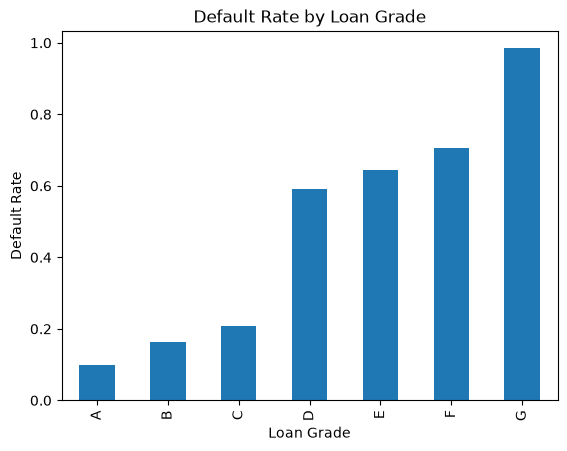

In [164]:
default_by_grade = df_clean.groupby("loan_grade")["loan_status"].mean()

default_by_grade.plot(kind="bar")

plt.title("Default Rate by Loan Grade")
plt.xlabel("Loan Grade")
plt.ylabel("Default Rate")
plt.show()

In [165]:
df_clean["income_ratio_band"] = pd.cut(
    df_clean["loan_percent_income"],
    bins=[0, 0.1, 0.2, 0.3, 0.4, 1],
    labels=["0-10%", "10-20%", "20-30%", "30-40%", "40%+"],
    include_lowest=True
)

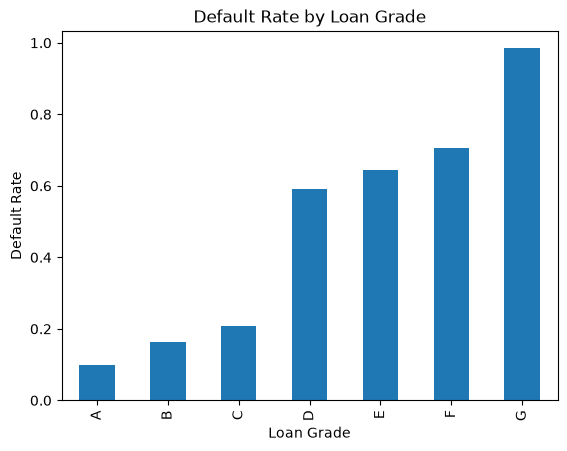

In [166]:
default_by_grade = df_clean.groupby("loan_grade")["loan_status"].mean()

default_by_grade.plot(kind="bar")

plt.title("Default Rate by Loan Grade")
plt.xlabel("Loan Grade")
plt.ylabel("Default Rate")
plt.show()

In [167]:
df_clean.groupby("income_ratio_band", observed=True)["loan_status"].agg(["count", "mean"])

,count,mean
income_ratio_band,,
0-10%,10484,0.117226
10-20%,12066,0.151086
20-30%,6197,0.219461
30-40%,2714,0.687178
40%+,1120,0.741964


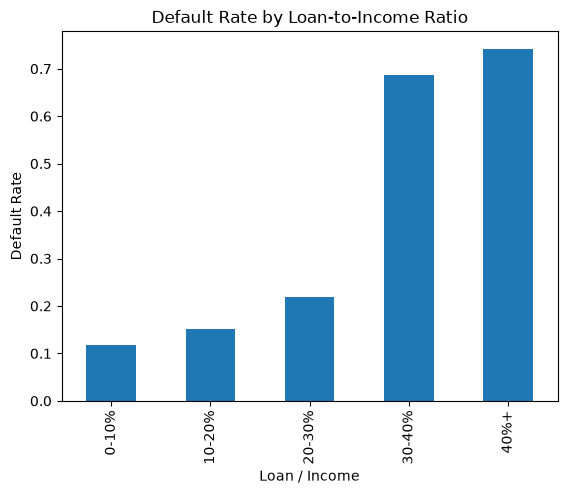

In [168]:
default_by_income_ratio = (
    df_clean.groupby("income_ratio_band", observed=True)["loan_status"].mean()
)

default_by_income_ratio.plot(kind="bar")

plt.title("Default Rate by Loan-to-Income Ratio")
plt.xlabel("Loan / Income")
plt.ylabel("Default Rate")
plt.show()

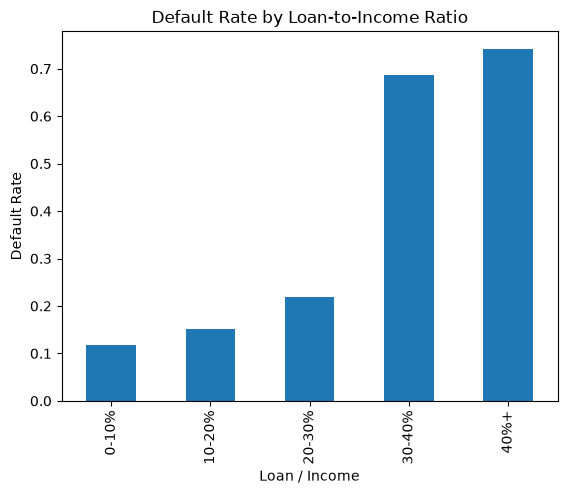

In [169]:
default_by_income_ratio = (
    df_clean
    .groupby("income_ratio_band", observed=True)["loan_status"]
    .mean()
)

default_by_income_ratio.plot(kind="bar")

plt.title("Default Rate by Loan-to-Income Ratio")
plt.xlabel("Loan / Income")
plt.ylabel("Default Rate")
plt.show()

In [170]:
df_clean["interest_rate_band"] = pd.qcut(
    df_clean["loan_int_rate"],
    q=5,
    duplicates="drop"
)

In [171]:
df_clean.groupby(
    "interest_rate_band",
    observed=True
)["loan_status"].agg(["count", "mean"])

,count,mean
interest_rate_band,,
"(5.419, 7.51]",6016,0.087434
"(7.51, 10.25]",5988,0.135104
"(10.25, 11.86]",5779,0.165773
"(11.86, 13.92]",5814,0.206570
"(13.92, 23.22]",5868,0.506135


In [172]:
df_clean.duplicated().sum()

np.int64(165)

In [173]:
model_df = df_clean.drop(
    columns=["income_ratio_band", "interest_rate_band"]
).copy()

In [174]:
model_df.isnull().sum()

person_age                       5
person_income                    0
person_home_ownership            0
person_emp_length              897
loan_intent                      0
loan_grade                       0
loan_amnt                        0
loan_int_rate                 3116
loan_status                      0
loan_percent_income              0
cb_person_default_on_file        0
cb_person_cred_hist_length       0
dtype: int64

In [175]:
model_df.duplicated().sum()

np.int64(165)

In [176]:
model_df.isnull().sum()

person_age                       5
person_income                    0
person_home_ownership            0
person_emp_length              897
loan_intent                      0
loan_grade                       0
loan_amnt                        0
loan_int_rate                 3116
loan_status                      0
loan_percent_income              0
cb_person_default_on_file        0
cb_person_cred_hist_length       0
dtype: int64

In [177]:
X = model_df.drop(columns=["loan_status"])
y = model_df["loan_status"]

In [178]:
from sklearn.model_selection import train_test_split

In [179]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

In [180]:
print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("y_train:", y_train.shape)
print("y_test:", y_test.shape)

X_train: (26064, 11)
X_test: (6517, 11)
y_train: (26064,)
y_test: (6517,)


In [181]:
print("Default rate train:", y_train.mean())
print("Default rate test:", y_test.mean())

Default rate train: 0.21815531000613875
Default rate test: 0.21819855761853613


In [182]:
X_train = X_train.copy()
X_test = X_test.copy()

In [183]:
missing_cols = [
    "person_age",
    "person_emp_length",
    "loan_int_rate"
]

In [184]:
train_medians = X_train[missing_cols].median()

train_medians

person_age           26.00
person_emp_length     4.00
loan_int_rate        10.99
dtype: float64

In [185]:
X_train[missing_cols] = X_train[missing_cols].fillna(train_medians)

X_test[missing_cols] = X_test[missing_cols].fillna(train_medians)

In [186]:
print("Missing en train:")
print(X_train.isnull().sum())

print("\nMissing en test:")
print(X_test.isnull().sum())

Missing en train:
person_age                    0
person_income                 0
person_home_ownership         0
person_emp_length             0
loan_intent                   0
loan_grade                    0
loan_amnt                     0
loan_int_rate                 0
loan_percent_income           0
cb_person_default_on_file     0
cb_person_cred_hist_length    0
dtype: int64

Missing en test:
person_age                    0
person_income                 0
person_home_ownership         0
person_emp_length             0
loan_intent                   0
loan_grade                    0
loan_amnt                     0
loan_int_rate                 0
loan_percent_income           0
cb_person_default_on_file     0
cb_person_cred_hist_length    0
dtype: int64


In [187]:
categorical_cols = [
    "person_home_ownership",
    "loan_intent",
    "loan_grade",
    "cb_person_default_on_file"
]

In [188]:
X_train_encoded = pd.get_dummies(
    X_train,
    columns=categorical_cols,
    drop_first=True,
    dtype=int
)

X_test_encoded = pd.get_dummies(
    X_test,
    columns=categorical_cols,
    drop_first=True,
    dtype=int
)

In [189]:
X_test_encoded = X_test_encoded.reindex(
    columns=X_train_encoded.columns,
    fill_value=0
)

In [190]:
print("Antes:")
print(X_train.shape)

print("Después del encoding:")
print(X_train_encoded.shape)

Antes:
(26064, 11)
Después del encoding:
(26064, 22)


In [191]:
X_train_encoded.head()

,person_age,person_income,person_emp_length,loan_amnt,loan_int_rate,loan_percent_income,cb_person_cred_hist_length,person_home_ownership_OTHER,person_home_ownership_OWN,person_home_ownership_RENT,...,loan_intent_MEDICAL,loan_intent_PERSONAL,loan_intent_VENTURE,loan_grade_B,loan_grade_C,loan_grade_D,loan_grade_E,loan_grade_F,loan_grade_G,cb_person_default_on_file_Y
15884,25.0,241875,4.0,16000,7.05,0.07,4,0,0,0,...,0,0,0,0,0,0,0,0,0,0
15138,21.0,18000,5.0,1500,12.18,0.08,4,0,0,1,...,0,1,0,1,0,0,0,0,0,0
7474,25.0,53000,10.0,16000,12.53,0.30,2,0,0,0,...,1,0,0,1,0,0,0,0,0,0
18212,28.0,16800,4.0,5000,13.98,0.30,8,0,1,0,...,1,0,0,0,1,0,0,0,0,0
6493,25.0,50000,2.0,10000,7.90,0.20,2,0,0,0,...,0,0,1,0,0,0,0,0,0,0


In [192]:
numeric_cols = [
    "person_age",
    "person_income",
    "person_emp_length",
    "loan_amnt",
    "loan_int_rate",
    "loan_percent_income",
    "cb_person_cred_hist_length"
]

In [193]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

In [194]:
X_train_encoded[numeric_cols] = scaler.fit_transform(
    X_train_encoded[numeric_cols]
)

In [195]:
X_train_encoded[numeric_cols] = scaler.fit_transform(
    X_train_encoded[numeric_cols]
)

In [196]:
X_train_encoded[numeric_cols] = scaler.fit_transform(
    X_train_encoded[numeric_cols]
)

X_test_encoded[numeric_cols] = scaler.transform(
    X_test_encoded[numeric_cols]
)

In [197]:
X_train_encoded.head()

,person_age,person_income,person_emp_length,loan_amnt,loan_int_rate,loan_percent_income,cb_person_cred_hist_length,person_home_ownership_OTHER,person_home_ownership_OWN,person_home_ownership_RENT,...,loan_intent_MEDICAL,loan_intent_PERSONAL,loan_intent_VENTURE,loan_grade_B,loan_grade_C,loan_grade_D,loan_grade_E,loan_grade_F,loan_grade_G,cb_person_default_on_file_Y
15884,-0.436298,2.759666,-0.191578,1.021455,-1.288396,-0.937956,-0.442817,0,0,0,...,0,0,0,0,0,0,0,0,0,0
15138,-1.087074,-0.754040,0.059518,-1.281664,0.379327,-0.844328,-0.442817,0,0,1,...,0,1,0,1,0,0,0,0,0,0
7474,-0.436298,-0.204717,1.314997,1.021455,0.493109,1.215493,-0.938514,0,0,0,...,1,0,0,1,0,0,0,0,0,0
18212,0.051784,-0.772874,-0.191578,-0.725739,0.964493,1.215493,0.548578,0,1,0,...,1,0,0,0,1,0,0,0,0,0
6493,-0.436298,-0.251802,-0.693770,0.068440,-1.012068,0.279211,-0.938514,0,0,0,...,0,0,1,0,0,0,0,0,0,0


In [198]:
from sklearn.linear_model import LogisticRegression

## 4. Logistic Regression

In [199]:
log_model = LogisticRegression(max_iter=1000)

In [200]:
log_model.fit(X_train_encoded, y_train)

,"max_iter max_iter: int, default=100Maximum number of iterations taken for the solvers to converge.",1000
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is '

In [201]:
y_pred = log_model.predict(X_test_encoded)

y_pred_proba = log_model.predict_proba(X_test_encoded)[:, 1]

In [202]:
print(y_pred[:10])
print(y_pred_proba[:10])

[0 0 0 0 0 0 0 0 0 0]
[0.00000000e+000 0.00000000e+000 0.00000000e+000 0.00000000e+000
 4.84805762e-021 6.33197129e-275 0.00000000e+000 0.00000000e+000
 1.21971334e-212 0.00000000e+000]


In [203]:
X_test_encoded[numeric_cols].describe()

,person_age,person_income,person_emp_length,loan_amnt,loan_int_rate,loan_percent_income,cb_person_cred_hist_length
count,6517.000000,6.517000e+03,6.517000e+03,6517.000000,6517.000000,6.517000e+03,6517.000000
mean,27.862053,6.620023e+04,4.751573e+00,9670.385147,10.995418,1.703023e-01,5.874482
std,6.429470,5.450896e+04,3.974883e+00,6425.478279,3.103718,1.066870e-01,4.134393
min,20.000000,5.500000e+03,-9.814126e-18,500.000000,5.420000,2.071871e-17,2.000000
25%,23.000000,3.900000e+04,2.000000e+00,5000.000000,8.490000,9.000000e-02,3.000000
50%,26.000000,5.500000e+04,4.000000e+00,8000.000000,10.990000,1.500000e-01,4.000000
75%,30.000000,8.000000e+04,7.000000e+00,12500.000000,13.110000,2.300000e-01,8.000000
max,80.000000,1.900000e+06,4.100000e+01,35000.000000,23.220000,7.600000e-01,30.000000


In [204]:
X_train_encoded = pd.get_dummies(
    X_train,
    columns=categorical_cols,
    drop_first=True,
    dtype=int
)

X_test_encoded = pd.get_dummies(
    X_test,
    columns=categorical_cols,
    drop_first=True,
    dtype=int
)

X_test_encoded = X_test_encoded.reindex(
    columns=X_train_encoded.columns,
    fill_value=0
)

In [205]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

In [206]:
from sklearn.linear_model import LogisticRegression

log_model = LogisticRegression(max_iter=1000)

log_model.fit(X_train_encoded, y_train)

c:\Users\sathy\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\linear_model\_logistic.py:599: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


,"max_iter max_iter: int, default=100Maximum number of iterations taken for the solvers to converge.",1000
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is '

In [207]:
y_pred = log_model.predict(X_test_encoded)

y_pred_proba = log_model.predict_proba(X_test_encoded)[:, 1]

print(y_pred[:10])
print(y_pred_proba[:10])

[0 0 0 0 0 0 0 0 0 1]
[0.16992856 0.15796938 0.00085407 0.1359042  0.02123216 0.18986429
 0.02721176 0.08321266 0.11993256 0.68028488]


In [208]:
from sklearn.metrics import confusion_matrix, classification_report

print(confusion_matrix(y_test, y_pred))

[[4862  233]
 [ 780  642]]


In [209]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.86      0.95      0.91      5095
           1       0.73      0.45      0.56      1422

    accuracy                           0.84      6517
   macro avg       0.80      0.70      0.73      6517
weighted avg       0.83      0.84      0.83      6517



In [210]:
y_pred_04 = (y_pred_proba >= 0.40).astype(int)

In [211]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred_04))

              precision    recall  f1-score   support

           0       0.88      0.93      0.91      5095
           1       0.69      0.57      0.62      1422

    accuracy                           0.85      6517
   macro avg       0.79      0.75      0.76      6517
weighted avg       0.84      0.85      0.84      6517



In [212]:
y_pred_03 = (y_pred_proba >= 0.30).astype(int)

print(classification_report(y_test, y_pred_03))

              precision    recall  f1-score   support

           0       0.91      0.87      0.89      5095
           1       0.59      0.70      0.64      1422

    accuracy                           0.83      6517
   macro avg       0.75      0.78      0.76      6517
weighted avg       0.84      0.83      0.83      6517



In [213]:
from sklearn.metrics import precision_score, recall_score, f1_score

thresholds = [0.10, 0.20, 0.30, 0.40, 0.50, 0.60, 0.70]

for threshold in thresholds:
    y_temp = (y_pred_proba >= threshold).astype(int)

    precision = precision_score(y_test, y_temp)
    recall = recall_score(y_test, y_temp)
    f1 = f1_score(y_test, y_temp)

    print(
        threshold,
        round(precision, 3),
        round(recall, 3),
        round(f1, 3)
    )

0.1 0.334 0.894 0.486
0.2 0.452 0.794 0.576
0.3 0.592 0.695 0.64
0.4 0.689 0.567 0.622
0.5 0.734 0.451 0.559
0.6 0.76 0.357 0.486
0.7 0.82 0.279 0.417


In [214]:
from sklearn.metrics import roc_auc_score

roc_auc = roc_auc_score(y_test, y_pred_proba)

print("ROC-AUC:", roc_auc)

ROC-AUC: 0.8443327826155369


In [215]:
from sklearn.metrics import roc_curve

fpr, tpr, thresholds_roc = roc_curve(y_test, y_pred_proba)

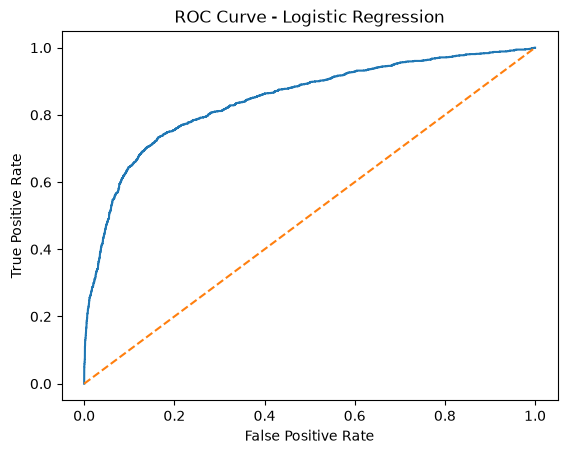

In [216]:
plt.plot(fpr, tpr)
plt.plot([0, 1], [0, 1], linestyle="--")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Logistic Regression")

plt.show()

In [217]:
gini = 2 * roc_auc - 1
print("Gini:", gini)

Gini: 0.6886655652310738


In [218]:
ks_index = ks_values.argmax()

ks_threshold = thresholds_roc[ks_index]

print("KS:", ks)
print("Threshold at max KS:", ks_threshold)
print("TPR at max KS:", tpr[ks_index])
print("FPR at max KS:", fpr[ks_index])

KS: 0.5686883116703864
Threshold at max KS: 0.2722840490092182
TPR at max KS: 0.7327707454289732
FPR at max KS: 0.16408243375858686


In [219]:
thresholds = [0.10, 0.20, 0.272, 0.30, 0.40, 0.50]

In [220]:
ks_values = tpr - fpr

ks = ks_values.max()

print("KS:", ks)

KS: 0.5686883116703864


In [221]:
coefficients = pd.DataFrame({
    "variable": X_train_encoded.columns,
    "coefficient": log_model.coef_[0]
})

coefficients = coefficients.sort_values(
    by="coefficient",
    ascending=False
)

coefficients

,variable,coefficient
17,loan_grade_D,1.170641
18,loan_grade_E,0.720046
9,person_home_ownership_RENT,0.704781
11,loan_intent_HOMEIMPROVEMENT,0.476990
5,loan_percent_income,0.405057
19,loan_grade_F,0.238149
21,cb_person_default_on_file_Y,0.234848
4,loan_int_rate,0.169006
20,loan_grade_G,0.108787
6,cb_person_cred_hist_length,0.077393


In [222]:
import sys
!{sys.executable} -m pip install xgboost

## 5. XGBoost

In [223]:
from xgboost import XGBClassifier

In [224]:
xgb_model = XGBClassifier(
    n_estimators=200,
    max_depth=3,
    learning_rate=0.05,
    random_state=42,
    eval_metric="logloss"
)

In [225]:
xgb_model.fit(X_train_encoded, y_train)

,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API <callback_api>`... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,None
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,True
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes from sklearn.metrics import mean_absolute_error X, y = load_diabetes(return_X_y=True) reg = xgb.XGBRegressor( tree_method=""hist"", eval_metric=mean_absolute_error, ) reg.fit(X, y, eval_set=[(X, y)])",'logloss'
,feature_types feature_types: typing.Optional[typing.Sequence[str]].. versionadded:: 1.7.0Used for specifying feature types without constructing a dataframe. Seethe :py:class:`DMatrix` for details.,None


In [226]:
xgb_pred = xgb_model.predict(X_test_encoded)
xgb_pred_proba = xgb_model.predict_proba(X_test_encoded)[:, 1]

In [227]:
from sklearn.metrics import classification_report

print(classification_report(y_test, xgb_pred))

              precision    recall  f1-score   support

           0       0.92      0.98      0.95      5095
           1       0.91      0.70      0.79      1422

    accuracy                           0.92      6517
   macro avg       0.92      0.84      0.87      6517
weighted avg       0.92      0.92      0.91      6517



In [228]:
from sklearn.metrics import roc_curve

xgb_fpr, xgb_tpr, xgb_thresholds = roc_curve(
    y_test,
    xgb_pred_proba
)

xgb_ks_values = xgb_tpr - xgb_fpr
xgb_ks = xgb_ks_values.max()

xgb_ks_index = xgb_ks_values.argmax()

print("XGBoost KS:", xgb_ks)
print(
    "Threshold at max KS:",
    xgb_thresholds[xgb_ks_index]
)

XGBoost KS: 0.6959169589335674
Threshold at max KS: 0.22862403094768524


In [229]:
print(classification_report(y_test, xgb_pred))

              precision    recall  f1-score   support

           0       0.92      0.98      0.95      5095
           1       0.91      0.70      0.79      1422

    accuracy                           0.92      6517
   macro avg       0.92      0.84      0.87      6517
weighted avg       0.92      0.92      0.91      6517



In [230]:
feature_importance = pd.DataFrame({
    "variable": X_train_encoded.columns,
    "importance": xgb_model.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by="importance",
    ascending=False
)

feature_importance

,variable,importance
5,loan_percent_income,0.231383
9,person_home_ownership_RENT,0.137347
4,loan_int_rate,0.108336
17,loan_grade_D,0.089557
16,loan_grade_C,0.060060
1,person_income,0.057599
8,person_home_ownership_OWN,0.045392
2,person_emp_length,0.032615
11,loan_intent_HOMEIMPROVEMENT,0.032443
12,loan_intent_MEDICAL,0.027140


In [233]:
feature_importance = pd.DataFrame({
    "variable": X_train_encoded.columns,
    "importance": xgb_model.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by="importance",
    ascending=False
)

feature_importance

,variable,importance
5,loan_percent_income,0.231383
9,person_home_ownership_RENT,0.137347
4,loan_int_rate,0.108336
17,loan_grade_D,0.089557
16,loan_grade_C,0.060060
1,person_income,0.057599
8,person_home_ownership_OWN,0.045392
2,person_emp_length,0.032615
11,loan_intent_HOMEIMPROVEMENT,0.032443
12,loan_intent_MEDICAL,0.027140


In [231]:
xgb_gini = 2 * xgb_auc - 1

print("XGBoost Gini:", xgb_gini)

XGBoost Gini: 0.8497599063641721


In [232]:
from sklearn.metrics import roc_auc_score

xgb_auc = roc_auc_score(y_test, xgb_pred_proba)

print("XGBoost ROC-AUC:", xgb_auc)

XGBoost ROC-AUC: 0.924879953182086


## 6. Model Comparison

In [238]:
comparison = pd.DataFrame({
    "Model": ["Logistic Regression", "XGBoost"],
    "ROC_AUC": [roc_auc, xgb_auc],
    "Gini": [gini, xgb_gini],
    "KS": [ks, xgb_ks],
    "Default_Precision": [0.73, 0.91],
    "Default_Recall": [0.45, 0.70],
    "Default_F1": [0.56, 0.79],
    "Accuracy": [0.84, 0.92]
})

comparison.round(3)

,Model,ROC_AUC,Gini,KS,Default_Precision,Default_Recall,Default_F1,Accuracy
0,Logistic Regression,0.844,0.689,0.569,0.73,0.45,0.56,0.84
1,XGBoost,0.925,0.850,0.696,0.91,0.70,0.79,0.92


### Model Selection

XGBoost was selected as the final model due to its superior discriminatory performance across all evaluation metrics.

Compared with Logistic Regression, XGBoost achieved higher ROC-AUC, Gini and KS statistics, while also substantially improving precision, recall and F1-score for the default class.

Logistic Regression remains useful as an interpretable benchmark, while XGBoost provides the strongest predictive performance in this dataset.

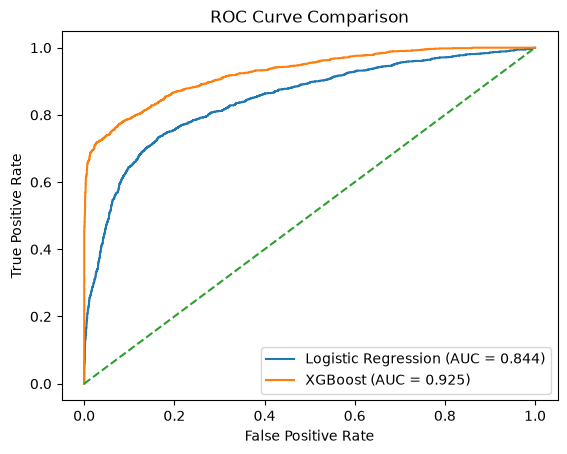

In [236]:
plt.plot(fpr, tpr, label=f"Logistic Regression (AUC = {roc_auc:.3f})")
plt.plot(xgb_fpr, xgb_tpr, label=f"XGBoost (AUC = {xgb_auc:.3f})")
plt.plot([0, 1], [0, 1], linestyle="--")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison")
plt.legend()

plt.show()

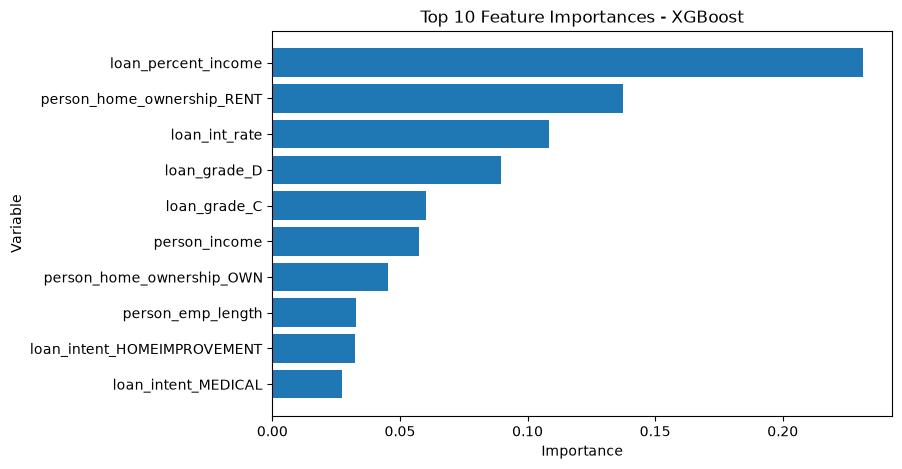

In [237]:
top_features = feature_importance.head(10)

plt.figure(figsize=(8, 5))

plt.barh(
    top_features["variable"],
    top_features["importance"]
)

plt.xlabel("Importance")
plt.ylabel("Variable")
plt.title("Top 10 Feature Importances - XGBoost")

plt.gca().invert_yaxis()

plt.show()

## 7. Final Conclusions

Final Conclusions

This project developed and compared two credit risk classification models to predict loan default.

The workflow included data quality checks, treatment of missing values and implausible observations, exploratory data analysis, categorical encoding, feature scaling, model training, threshold analysis and credit-risk-specific evaluation metrics.

The Logistic Regression model achieved:

ROC-AUC: 0.844
Gini: 0.689
KS: 0.569
Default recall at threshold 0.50: 0.45
Default F1-score: 0.56

XGBoost significantly improved predictive performance:

ROC-AUC: 0.925
Gini: 0.850
KS: 0.696
Default precision: 0.91
Default recall: 0.70
Default F1-score: 0.79
Accuracy: 0.92

The most important variables in the XGBoost model were loan_percent_income, person_home_ownership_RENT, loan_int_rate, loan_grade_D, loan_grade_C and person_income.

Overall, XGBoost was selected as the best-performing model, while Logistic Regression remains valuable as a more interpretable benchmark.